In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#import scienceplots
import uncertainties as unc
from uncertainties import unumpy as unp
from uncertainties import umath

import os
import utils as uts

from main_data_processor import Data
# plt.rcParams['text.usetex'] = False
#plt.style.use('science')

In [2]:
def plot_each_peg(dat, x_col, y_col, **kwargs):

    for crowder in dat['crowder'].unique():

        df = dat[dat['crowder'] == crowder]

        x = df[x_col]
        y = df[y_col]

        if x.dtype == unc.core.AffineScalarFunc:
            x = unp.nominal_values(x)

        if y.dtype == unc.core.AffineScalarFunc:
            y_nom = unp.nominal_values(y)
            y_err = unp.std_devs(y)


            plt.errorbar(x, y_nom, yerr=y_err, fmt='o', label=crowder, **kwargs)

        else:
            plt.plot(x, y, 'o', label=crowder)

    plt.legend()
    plt.xlabel(x_col)
    plt.ylabel(y_col)

In [3]:
equillibrium_constans_path = 'source_data/MacromoleculeEquilibria_Crowding'
complexation_data_path = 'source_data/IonCrowderComplexation/raw_data'
sodium_path = 'source_data/IonStrengthDependency/Na+_FRET.csv'



all_data =  Data(equillibrium_constans_path, complexation_data_path,sodium_path)

complexation_data = all_data.EquillbriumConstantsObj
equillibrium_constants = all_data.SodiumCrowderComplexationObj

# Sodium crowder complexation

In [4]:
# diffusion coefficient of the Na+ in ultra-pure water
equillibrium_constants.D_Na0

1425.622636

In [5]:
df = equillibrium_constants.analyzed_data

df

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,D_Na_uf_[um2/s],D_crowder_uf_[um2/s],MW_[g/mol],No_mono,...,mass concentration [g/cm3],concentration [M],monomers concentration [M],ksi,Reff,D_Na_[um2/s] corr,n Beta [1/M],chi2,redchi2,R^2
0,1.0,1412.3260,38.60817,586.6107,2.625764,PEG200,(1.41+/-0.04)e+03,586.6+/-2.6,200.0,4.131215,...,0.009987,0.049937,0.206301,12.088670,0.149132,1417.044932,1.06+/-0.06,4.84964,0.692806,0.956408
1,2.5,1284.2680,34.60799,563.1332,2.004906,PEG200,1284+/-35,563.1+/-2.0,200.0,4.131215,...,0.025034,0.125170,0.517104,6.068361,0.149132,1404.844680,1.06+/-0.06,4.84964,0.692806,0.956408
2,5.0,1255.0480,43.33636,526.7910,2.182739,PEG200,(1.26+/-0.04)e+03,526.8+/-2.2,200.0,4.131215,...,0.050286,0.251430,1.038712,3.596530,0.149132,1385.107831,1.06+/-0.06,4.84964,0.692806,0.956408
3,7.5,1191.7850,49.04247,494.5730,1.811948,PEG200,(1.19+/-0.05)e+03,494.6+/-1.8,200.0,4.131215,...,0.075756,0.378780,1.564823,2.644881,0.149132,1365.812914,1.06+/-0.06,4.84964,0.692806,0.956408
4,10.0,1142.1510,63.22156,462.2113,2.106704,PEG200,(1.14+/-0.06)e+03,462.2+/-2.1,200.0,4.131215,...,0.101444,0.507220,2.095437,2.124707,0.149132,1346.836996,1.06+/-0.06,4.84964,0.692806,0.956408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,7.5,1194.5400,87.02829,266.2855,0.832020,PEG600,(1.19+/-0.09)e+03,266.3+/-0.8,600.0,13.211805,...,0.075756,0.126260,1.668124,2.707354,0.164505,1359.899014,2.41+/-0.35,8.85825,1.476375,0.903605
85,10.0,1107.9380,139.25370,239.8183,0.763911,PEG600,(1.11+/-0.14)e+03,239.8+/-0.8,600.0,13.211805,...,0.101444,0.169073,2.233766,2.174893,0.164505,1339.107012,2.41+/-0.35,8.85825,1.476375,0.903605
86,12.5,1042.4860,83.72489,219.9866,0.725046,PEG600,(1.04+/-0.08)e+03,220.0+/-0.7,600.0,13.211805,...,0.127350,0.212250,2.804209,1.833827,0.164505,1318.630882,2.41+/-0.35,8.85825,1.476375,0.903605
87,15.0,895.3644,62.98626,198.7878,0.777237,PEG600,(9.0+/-0.6)e+02,198.8+/-0.8,600.0,13.211805,...,0.153474,0.255790,3.379452,1.594342,0.164505,1298.433861,2.41+/-0.35,8.85825,1.476375,0.903605


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


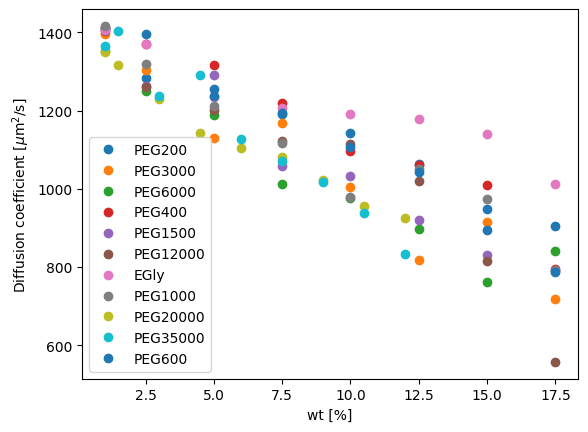

In [6]:
plot_each_peg(df, 'wt_%', 'D_Na_[um2/s]')
plt.xlabel('wt [%]')
plt.ylabel(r'Diffusion coefficient [$\mu$m$^2$/s]')
plt.savefig('./plots/plots_for_publication/sodium_in_PEGs.png', dpi=600)
plt.legend()

### Nanosiscosity effects

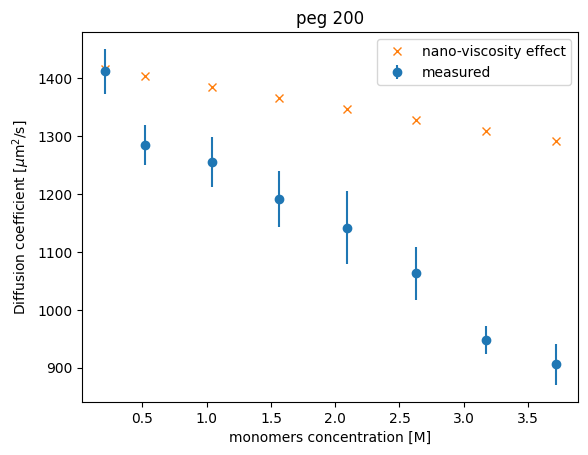

In [7]:
peg200 = df[df['crowder'] == 'PEG200']


D_measured, D_measured_err = uts.get_float_uncertainty(peg200['D_Na_uf_[um2/s]'])

D_viscosity = peg200['D_Na_[um2/s] corr']


plt.errorbar( peg200['monomers concentration [M]'] , D_measured, yerr=D_measured_err, fmt='o', label='measured')
plt.plot( peg200['monomers concentration [M]'] , D_viscosity, 'x',  label='nano-viscosity effect')
plt.title('peg 200')
plt.xlabel('monomers concentration [M]')
plt.ylabel(r'Diffusion coefficient [$\mu$m$^2$/s]')
plt.legend()
plt.savefig('./plots/plots_for_publication/nanoviscosity_effect.png', dpi=600)

# nBeta as a function of monomer number

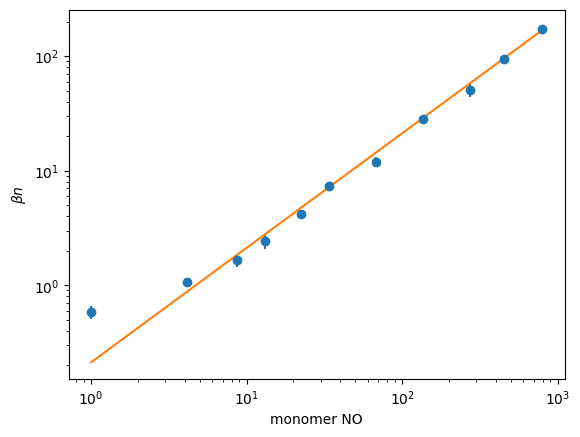

In [8]:
x = df['No_mono'].unique()
y, y_err = uts.get_float_uncertainty(df['n Beta [1/M]'].unique())

a = np.dot(x, y) / np.dot(x, x)

x_int = np.linspace(min(x), max(x))

plt.errorbar(x, y, y_err, fmt='o', label='experimental')
plt.plot(x_int, a * x_int)
plt.xlabel('monomer NO')
plt.ylabel(r'$\beta n$')
plt.xscale('log')
plt.yscale('log')
plt.savefig('./plots/plots_for_publication/Bn_mon_NO.png', dpi=600)

# Ion concentration dependency 

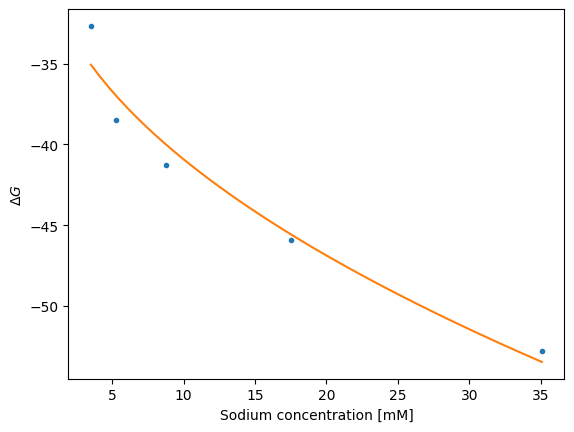

In [9]:
ion_df = all_data.SodiumDependencyObj

conc = ion_df.raw_data['C_Na+_[mM]']
conc_fit = np.linspace(conc.min(), conc.max())

popt = ion_df.popt_eff


plt.plot(conc, ion_df.raw_data['dG_[kJ/mol]'], '.')
plt.plot(conc_fit, ion_df.model(conc_fit, *popt))
plt.xlabel('Sodium concentration [mM]')
plt.ylabel(r'$\Delta G$')
plt.savefig('plots/plots_for_publication/sodium_dependency.png', dpi=600)

In [10]:
popt

array([-26.56305425,   4.5408118 ])

# Gibbs Free Energy

In [11]:
data = all_data.data

data.columns

Index(['crowder', 'crowder wt. [%]', 'sample', 'charge 1', 'charge 2',
       'Rg 1 [nm]', 'Rg 2 [nm]', 'T [K]', 'Na conc. [mM]', 'I [mM]',
       'molar mass [g/mol]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]',
       'No_mono', 'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]',
       'V_Rg_[nm3]', 'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]',
       'mass_concentration_[g/mL]', 'c*_[M]', 'c/c*', 'a2_exp', 'a1_exp',
       'a0_exp', 'chi2', 'chi2_red', 'R2', 'nBeta_[1/M]', 'Na_free_[mM]',
       'dG_Na_[kJ/mol]', 'dG_exp_[kJ/mol]'],
      dtype='object')

In [13]:
# Removing the 50% concentration
data = data[data['crowder wt. [%]'] < 50]

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


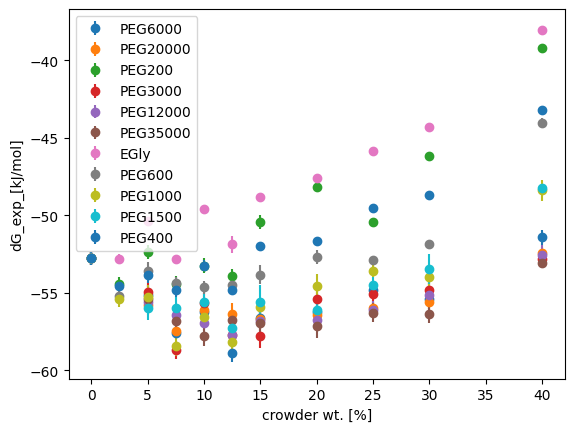

In [14]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_exp_[kJ/mol]')
plt.savefig('./plots/plots_for_publication/deltaG_experimental.png', dpi=600)

# Minima of the Delta G

In [15]:
data['deltaG_minima'] = -data['a1_exp']/(2 * data['a2_exp']) /data['c*_[M]']

/tmp/ipykernel_30835/1589486482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['deltaG_minima'] = -data['a1_exp']/(2 * data['a2_exp']) /data['c*_[M]']


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


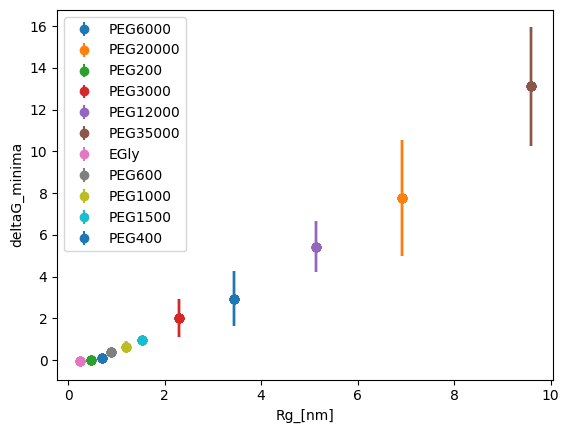

In [16]:
plot_each_peg(data, 'Rg_[nm]', 'deltaG_minima')
plt.savefig('./plots/plots_for_publication/deltaG_minimum.png', dpi=600)

# Sodium impact on the reaction free energy 

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


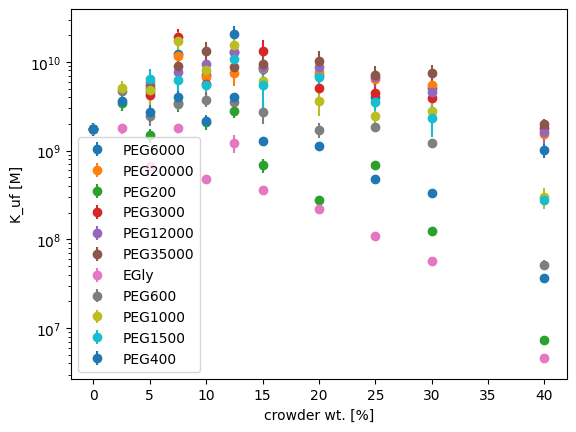

In [17]:
plot_each_peg(data, 'crowder wt. [%]', 'K_uf [M]')
plt.yscale('log')
plt.savefig('./plots/plots_for_publication/K_experimental.png', dpi=600)

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


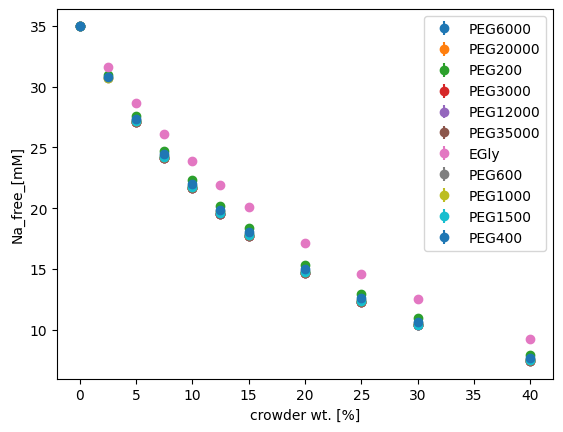

In [18]:
plot_each_peg(data, 'crowder wt. [%]', 'Na_free_[mM]')
plt.savefig('plots/plots_for_publication/free_sodium.png', dpi=600)

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


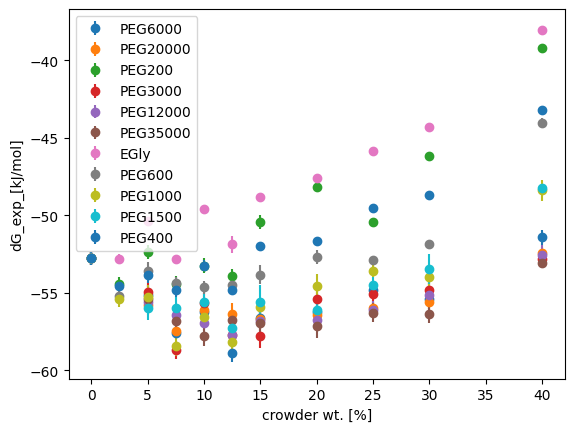

In [19]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_exp_[kJ/mol]')

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


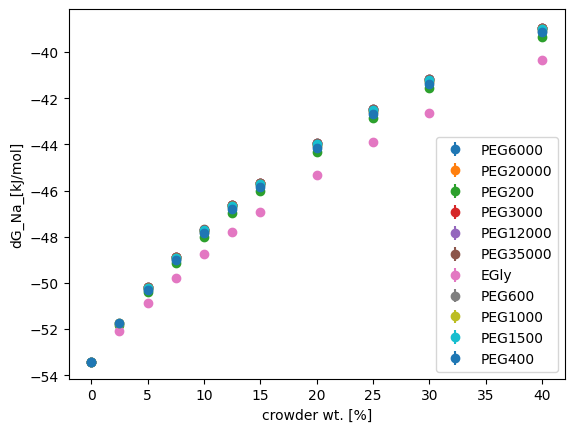

In [20]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_Na_[kJ/mol]')
plt.savefig('plots/plots_for_publication/impact_of_sodium_to_reaction.png', dpi=600)

# Analysis of the rest of free energy

/tmp/ipykernel_30835/1051262290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rest_dG_[kJ/mol]'] = data['dG_exp_[kJ/mol]'] - data['dG_Na_[kJ/mol]']
/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


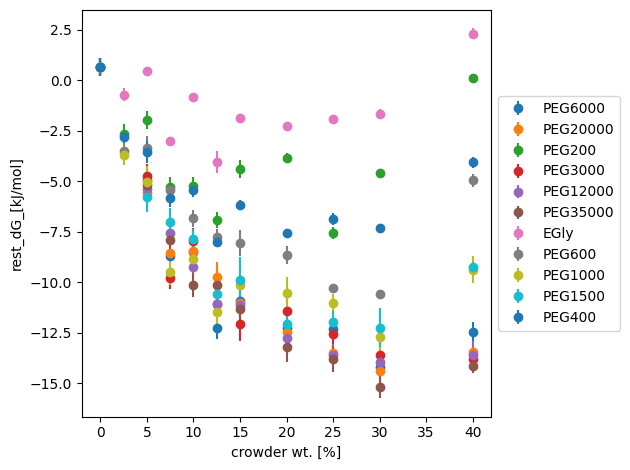

In [21]:
data['rest_dG_[kJ/mol]'] = data['dG_exp_[kJ/mol]'] - data['dG_Na_[kJ/mol]']

plot_each_peg(data, 'crowder wt. [%]', 'rest_dG_[kJ/mol]')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.plot()
plt.tight_layout()
plt.savefig('plots/plots_for_publication/rest_dG.png', dpi=600)

/tmp/ipykernel_30835/3611874334.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small['minus'] = -small['rest_dG_[kJ/mol]']
/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


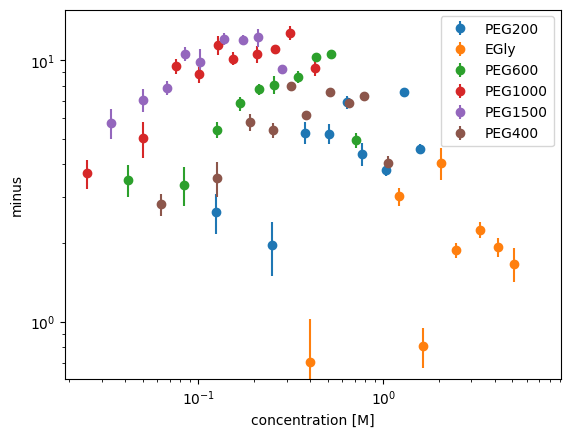

In [22]:
small = data[(data['molar mass [g/mol]'] < 3000) & (data['concentration [M]'] > 0)]


small['minus'] = -small['rest_dG_[kJ/mol]']

plot_each_peg(small, 'concentration [M]', 'minus')

plt.xscale('log')
plt.yscale('log')

# Calculating the PEG osmotic pressure:

In [23]:
df = data[(data['molar mass [g/mol]'] >= 3000) & (data['concentration [M]'] > 0)]

In [34]:
# parameters taken from paper (doi: 10.1021/jp806893a): 
V = 0.825 # ml/g  
alpha = 0.49


df['c*N_[ml/g]'] = df['No_mono'] ** (-4/5) / V

df['x'] = df['mass_concentration_[g/mL]']/df['c*N_[ml/g]']
df['log(x)'] = np.log10(df['x'])

df['y'] = np.log10(8.314 * 293.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) * 10 ** 7)

/tmp/ipykernel_30835/3074837908.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['c*N_[ml/g]'] = df['No_mono'] ** (-4/5) / V
/tmp/ipykernel_30835/3074837908.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x'] = df['mass_concentration_[g/mL]']/df['c*N_[ml/g]']
/tmp/ipykernel_30835/3074837908.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


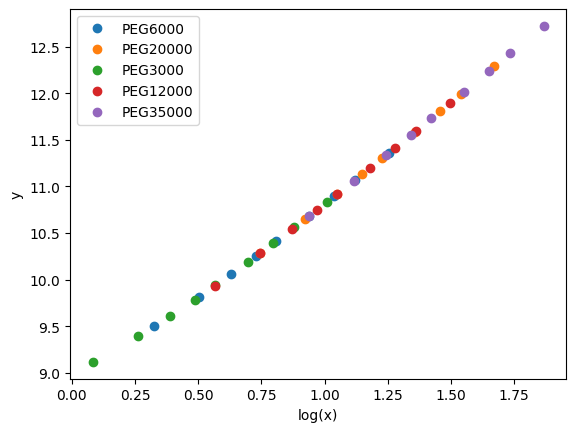

In [35]:
plot_each_peg(df, 'log(x)' ,'y')

# Literature

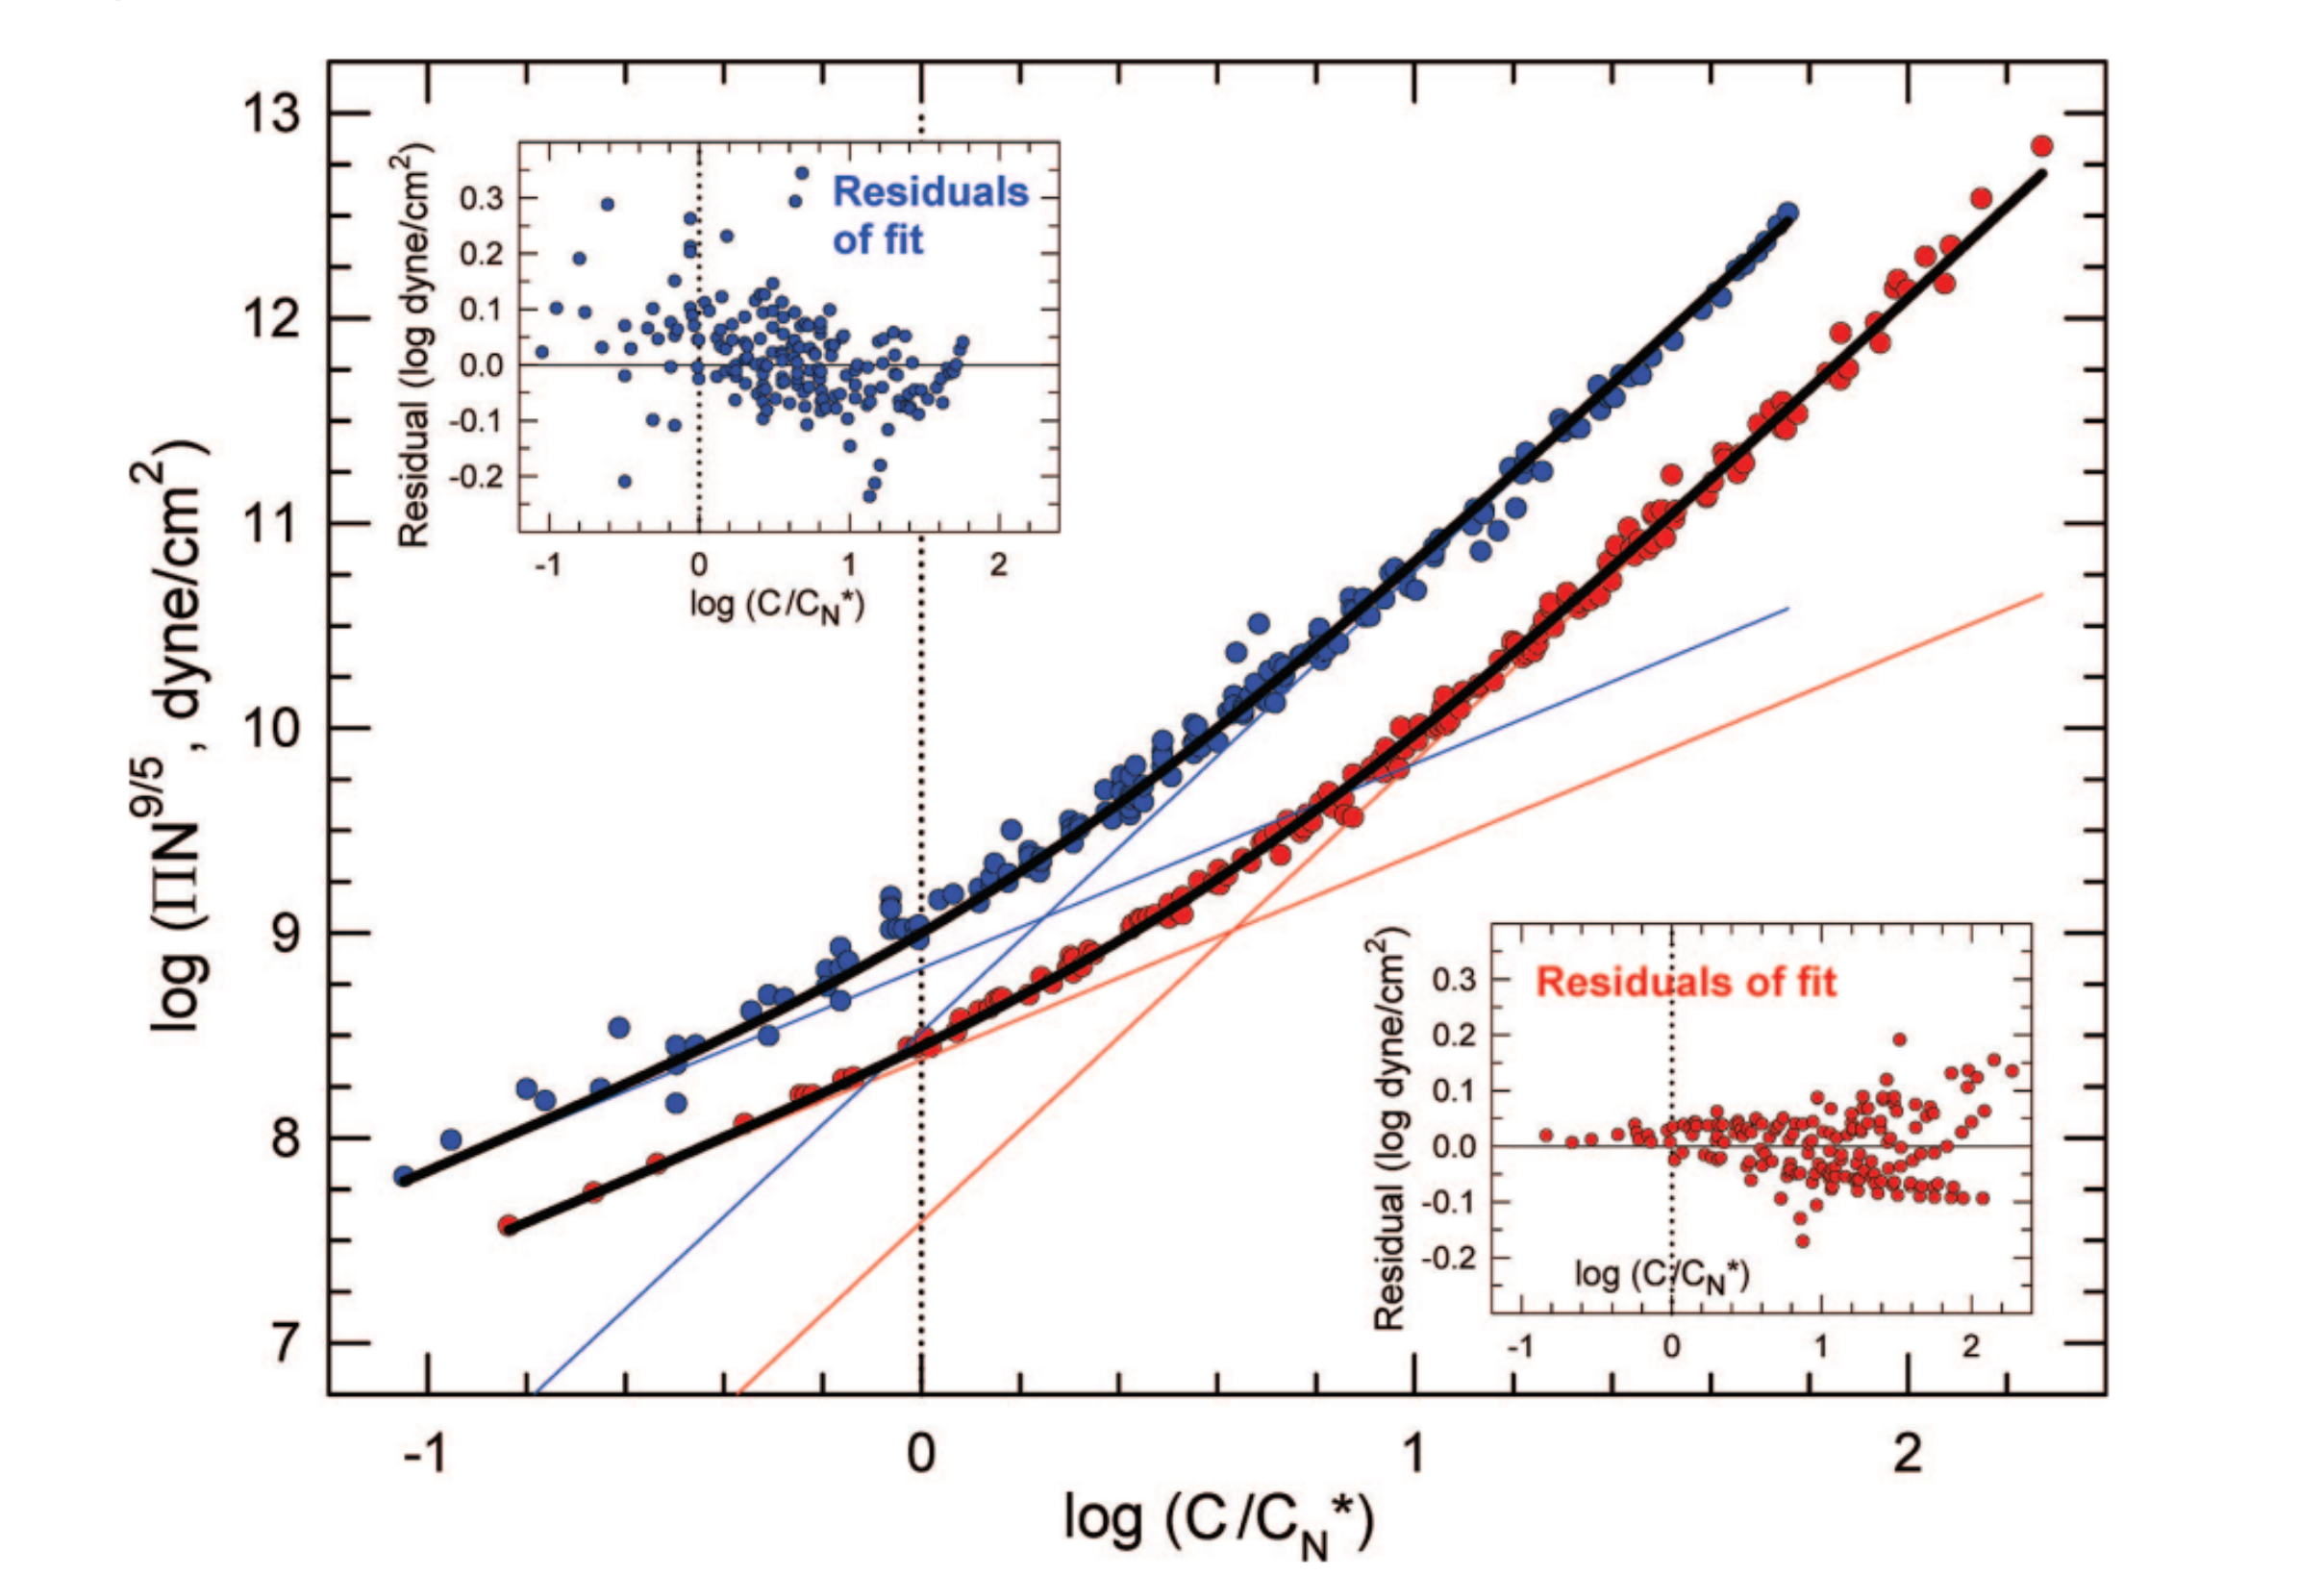

## source: doi: 10.1021/jp806893a, Figure 3

In [36]:
df['pi_[Pa]'] = 8.314 * 298.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) / df['No_mono'] ** (9/5) * 10 ** 6

/tmp/ipykernel_30835/3148064446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pi_[Pa]'] = 8.314 * 298.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) / df['No_mono'] ** (9/5) * 10 ** 6


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


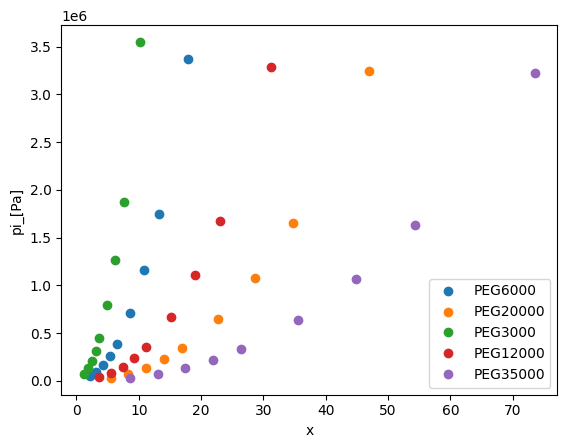

In [37]:
plot_each_peg(df, 'x', 'pi_[Pa]')

In [38]:
df['dG_rest/pi_[m3/mol]'] = -df['rest_dG_[kJ/mol]'] * 1000/df['pi_[Pa]']

/tmp/ipykernel_30835/4177060825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dG_rest/pi_[m3/mol]'] = -df['rest_dG_[kJ/mol]'] * 1000/df['pi_[Pa]']


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


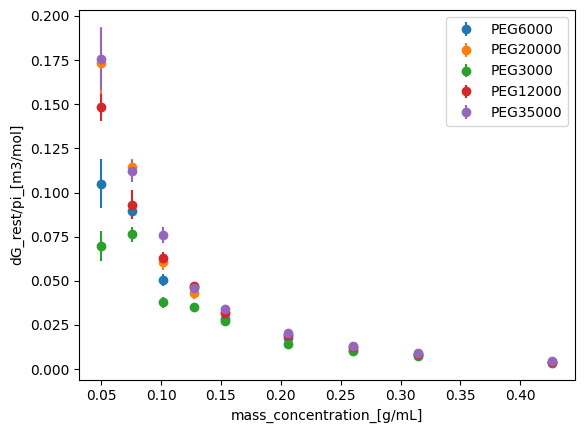

In [39]:
plot_each_peg(df, 'mass_concentration_[g/mL]', 'dG_rest/pi_[m3/mol]')

In [40]:
df['Veff_[nm3]'] = df['dG_rest/pi_[m3/mol]'] * 10 ** (27) / (6.02 * 10 ** (23))

/tmp/ipykernel_30835/3949307605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Veff_[nm3]'] = df['dG_rest/pi_[m3/mol]'] * 10 ** (27) / (6.02 * 10 ** (23))


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


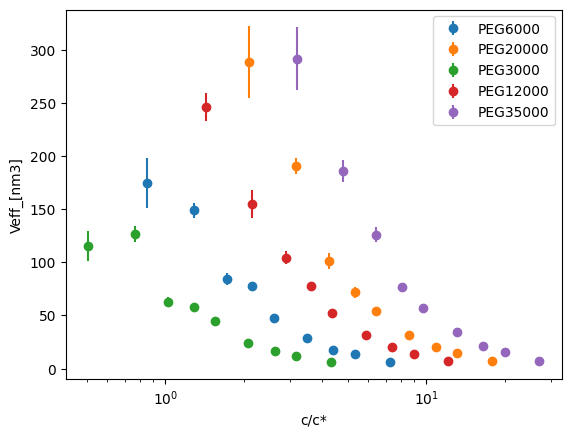

In [41]:
plot_each_peg(df, 'c/c*', 'Veff_[nm3]')
plt.xscale('log')
plt.savefig('plots/plots_for_publication/effective_volume.png')

In [32]:
#chosen = df[df['MW_[g/mol]'] > 1500]
df['V_eff/(Rg ksi)_[nm]'] = df['Veff_[nm3]']/ (df['Rg_[nm]'] * df['c/c*'] ** (-0.77)) / df['Rg_[nm]']

/tmp/ipykernel_30835/1344549981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['V_eff/(Rg ksi)_[nm]'] = df['Veff_[nm3]']/ (df['Rg_[nm]'] * df['c/c*'] ** (-0.77)) / df['Rg_[nm]']


/tmp/ipykernel_30835/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_30835/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


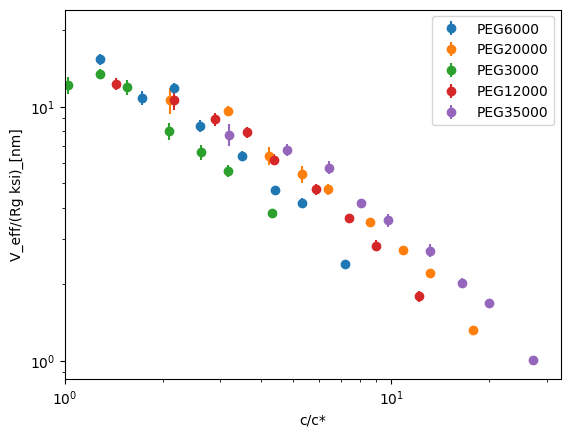

In [33]:
plot_each_peg(df, 'c/c*', 'V_eff/(Rg ksi)_[nm]')


plt.xscale('log')
plt.yscale('log')


plt.xlim(1)

plt.savefig('plots/plots_for_publication/depletion_scaling.png', dpi=600)